#Fashion MNIST
image classification with keras


In [1]:
import tensorflow as tf
from tensorflow import keras

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
print(tf.__version__)

2.2.0


In [5]:
#Importing the data
fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

4423680/4422102 [==============================] - 0s 0us/step


#Labels
      0 => T-shirt
      1 => Trouser
      2 => Pullover
      3 => Dress
      4 => Coat
      5 => Sandal
      6 => Shirt
      7 => Sneaker
      8 => Bag
      9 => Ankle Boot

In [40]:
class_names = ['T-shirt',
                 'Trouser',
               'Pullover',
               'Dress',
               'Coat',
               'Sandal',
               'Shirt',
               'Sneaker',
               'Bag',
               'Ankle Boo']

In [8]:
#Exploring the data
train_images.shape

(60000, 28, 28)

In [11]:
test_images.shape

(10000, 28, 28)

In [9]:
len(train_labels)

60000

In [10]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

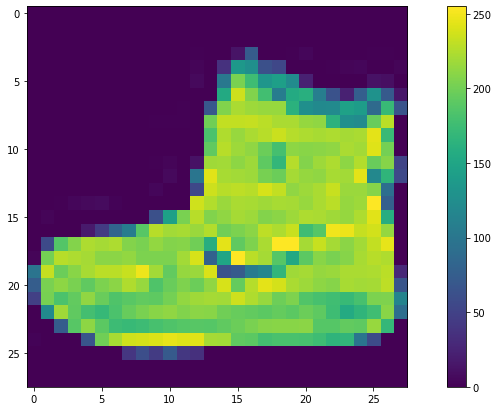

In [14]:
#Data preprocesing
plt.figure(figsize=(14,7))
plt.imshow(train_images[0])
plt.colorbar()

In [28]:
#Changing our values to range from 0 to 1
train_images = train_images / 255.0 #.0 is important it converts the num to float
test_images = test_images / 255.0

'Dress'

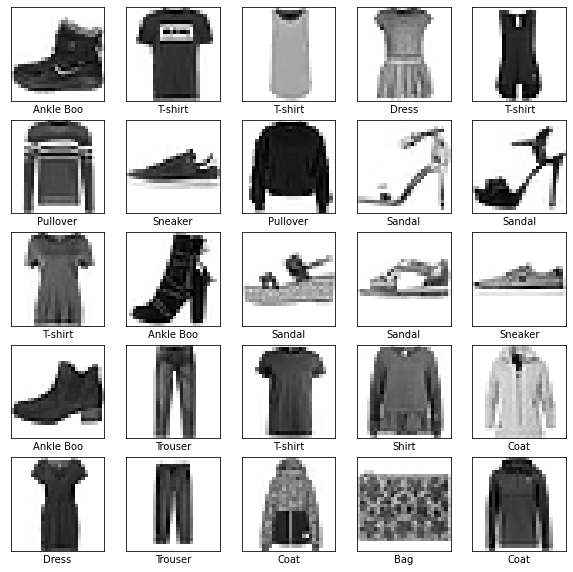

In [42]:
plt.figure(figsize=(10,10))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(train_images[i], cmap=plt.cm.binary)
  plt.xlabel(class_names[train_labels[i]])
plt.show()

In [53]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [54]:
#Setting up the neural network

model = Sequential()
model.add(Flatten(input_shape=(28,28))) # transform 28*28 to 784 vector
model.add(Dense(128, activation='relu')) # 784 -> 128 fully connected
model.add(Dense(10))# 784 -> 128 -> 10 #final layer

In [55]:
#Compile the model
model.compile(optimizer='adam',
              loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [58]:
#Training the model
model.fit(train_images, train_labels, epochs=25)

Epoch 1/25
1875/1875 [==============================] - 4s 2ms/step - loss: 0.4681 - accuracy: 0.8375
Epoch 2/25
1875/1875 [==============================] - 4s 2ms/step - loss: 0.4619 - accuracy: 0.8408
Epoch 3/25
1875/1875 [==============================] - 5s 2ms/step - loss: 0.4712 - accuracy: 0.8367
Epoch 4/25
1875/1875 [==============================] - 4s 2ms/step - loss: 0.4575 - accuracy: 0.8416
Epoch 5/25
1875/1875 [==============================] - 4s 2ms/step - loss: 0.4609 - accuracy: 0.8425
Epoch 6/25
1875/1875 [==============================] - 4s 2ms/step - loss: 0.4538 - accuracy: 0.8454
Epoch 7/25
1875/1875 [==============================] - 4s 2ms/step - loss: 0.4471 - accuracy: 0.8452
Epoch 8/25
1875/1875 [==============================] - 4s 2ms/step - loss: 0.4450 - accuracy: 0.8475
Epoch 9/25
1875/1875 [==============================] - 4s 2ms/step - loss: 0.4508 - accuracy: 0.8466
Epoch 10/25
1875/1875 [==============================] - 4s 2ms/step - loss: 0.451

In [59]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)

print('\nTest accuracy:{} & Test_loss:{}'.format(test_acc, test_loss))

313/313 - 0s - loss: 0.6634 - accuracy: 0.8339

Test accuracy:0.833899974822998 & Test_loss:0.6633789539337158


In [64]:
model.summary()

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_2 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_4 (Dense)              (None, 128)               100480    
_________________________________________________________________
dense_5 (Dense)              (None, 10)                1290      
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
_________________________________________________________________


In [65]:
#making predictions
from tensorflow.keras.layers import Softmax
proability_model = Sequential([model, Softmax()])

predictions = proability_model.predict(test_images)

In [70]:
predictions[7]

array([7.8848627e-04, 0.0000000e+00, 1.9078720e-03, 7.7052846e-07,
       1.2238349e-01, 0.0000000e+00, 8.7491947e-01, 0.0000000e+00,
       2.9045369e-16, 0.0000000e+00], dtype=float32)

In [71]:
np.argmax(predictions[7]) #Grabs the one with highest prediction

6

In [73]:
test_labels[7]

6

In [74]:
class_names[6]

'Shirt'

In [84]:
#Function that plots the image
def plot_image(index, predictions_array, true_label, img):
  
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img[index], cmap=plt.cm.binary)#Image

  predicted_label = np.argmax(predictions_array) #Class value

  if predicted_label == true_label[index]:
    color = 'blue' #Right guess
  else:
      color = 'red' #wrong guess

  plt.xlabel("{} {:2.0f}% ({})". format(class_names[predicted_label],
                                        
                                        100*np.max(predictions_array),

                                        class_names[true_label[index]]
                                      ),
                                        color = color
            )

In [85]:
def plot_value_array(index, predictions_array, true_label):
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0,1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label[index]].set_color('blue')

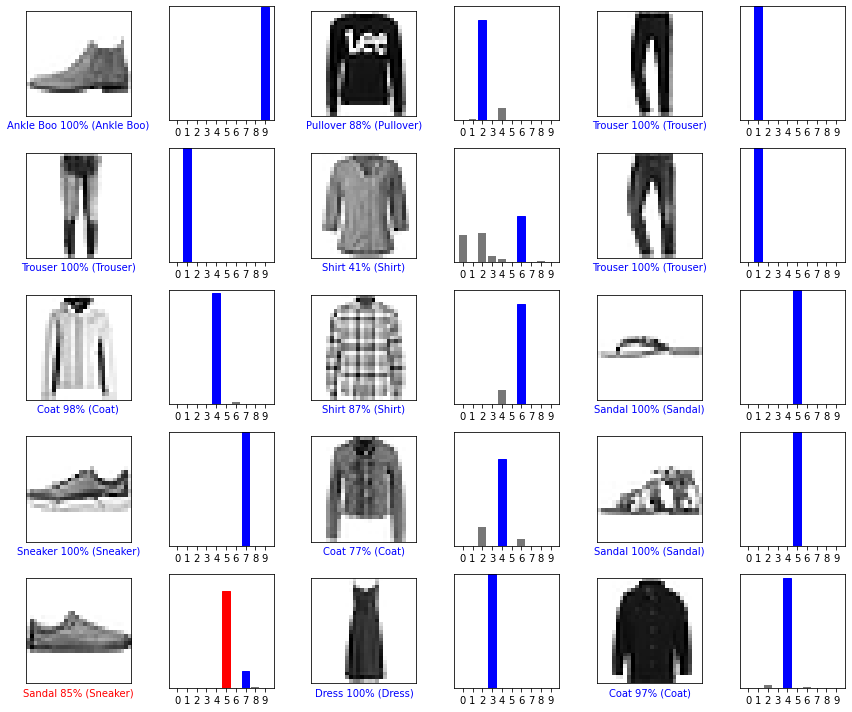

In [94]:
#Plotting the first 15 test images and their labels
# with predicted values on the side
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions[i], test_labels, test_images)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions[i], test_labels)
plt.tight_layout()
plt.show()
